In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [ ]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
colors = ['slateblue','tomato','darkseagreen','orchid','darkslategrey']#['b','red','g','darkorange','darkslategrey']#['orange','g','y','b','r']#['r', 'b', 'y', 'm', 'g']
masses =  [1.e-26, 1.e-25, 1.e-24, 1.e-23] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'tol_thermo_integration': 1.0e-5,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,
                 'Omega_cdm' : omega_cdm/h_planck**2, 'Omega_vf' : 0., 
                 'h' : h_planck,#'100*theta_s': theta_s,
                 'A_s' : As,
                 'n_s':ns,
                 'tau_reio':tau_reio,
                 'YHe': 'BBN',
                 'output' : 'tCl,pCl,lCl,mPk', 'P_k_max_h/Mpc' : 100., 'gauge':'synchronous', 'z_pk':'0,20',
                 'ic' : 'ad',
                 'modes' : 's', 'recombination' : 'RECFAST'}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)
lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()


frac = 1-1.e-6
common_settings  = {
            'h' : h_planck, #'100*theta_s': theta_s,
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'vf_tuning_index' : 3,
            'vector_background_mode': 'bianchi',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl,lCl,mPk',
            'ic' : 'ad',
            'P_k_max_h/Mpc' : 100.,'z_pk':'0,20',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'modes' : 's',
            'recombination' : 'RECFAST'
            }
common_settings.update(precision_settings) 

As a benchmark, let's define the LCDM cosmology.

# $\theta$ sweep

In [4]:
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']

### $m = 10^{-22} eV$

In [12]:
mass = 1.e-22
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

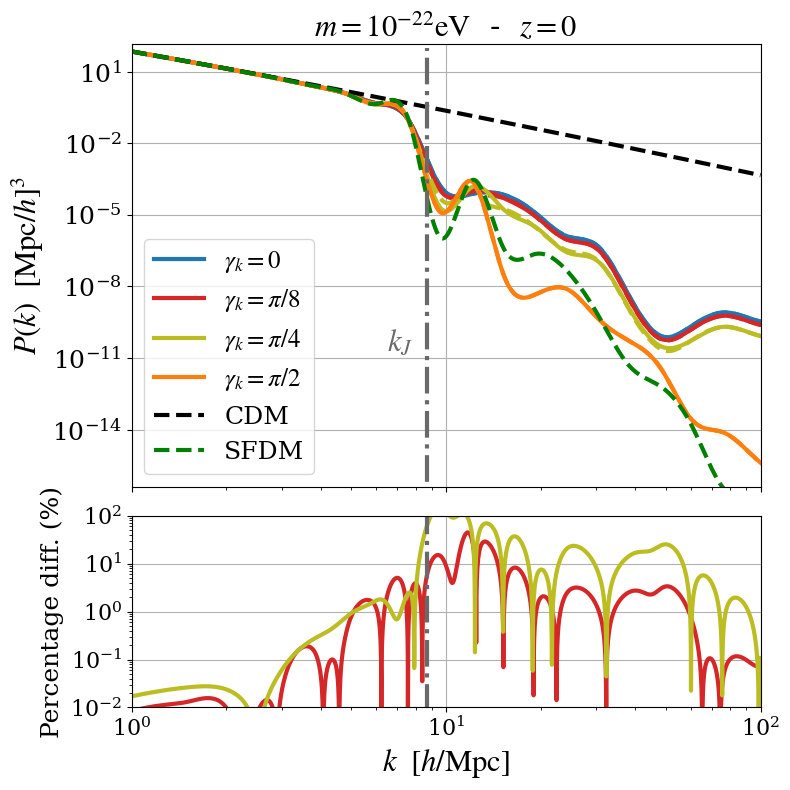

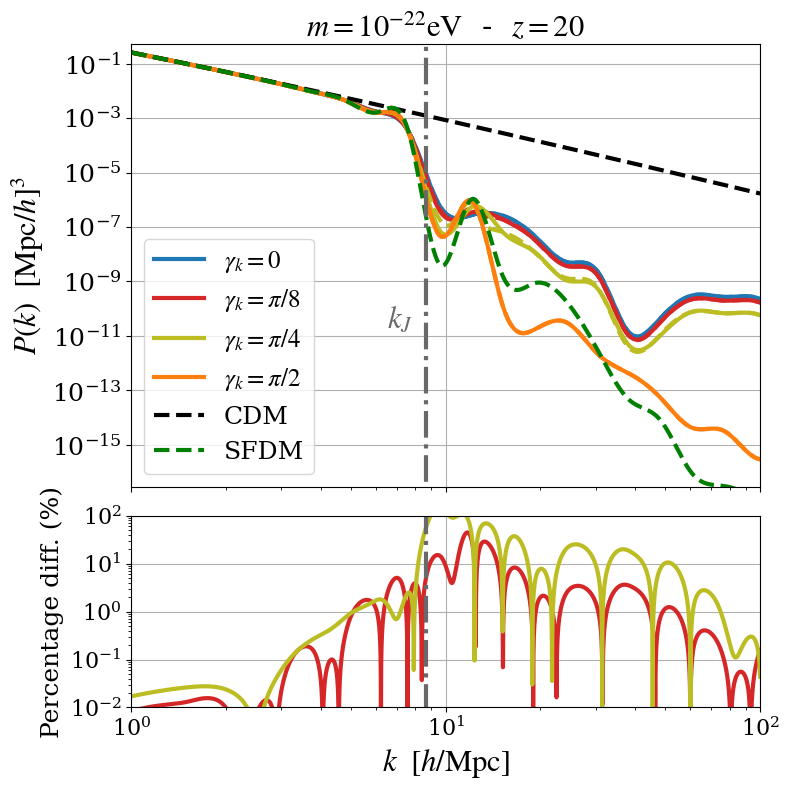

In [ ]:
# m = 10^{-22} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
def Pk_z0(z0, scalar=False):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(0, np.log10(100),5000) # k in h/Mpc

        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        Pk = [] # P(k) in (Mpc/h)**3

        a_plot = []
        b_plot = []
        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)

        data_scf = np.loadtxt('../../SFDM_data/Pk_SFDM/Pk_SFDM_m=%s_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        k_scf = data_scf[:,0]  # first column
        Pk_sfdm = data_scf[:,1]  # second column   
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i]) * np.cos(angles[m])**(4)  for i in range(len(kk))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        if angles[m] == angles[-1]:
            if scalar==True:
                Pk_scalar = np.loadtxt('SFDM_data/Pk_SFDM/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
                axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
                axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[0].loglog(k_scf, Pk_sfdm, 'g--', label=r'SFDM', lw=3)
            
            axes[0].legend(loc='lower left',fontsize=18)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    axes[0].set_xlim([1.e0, 1.e2])
    axes[0].vlines(kj/h, 1.-17, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=22)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=22)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=18)
    axes[0].text(0.75*kj/h, 2.e-11, r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=22)
    axes[0].set_title(r'$m = 10^{%s} \rm{eV}$  -  $z = %s$' % (str(mass)[-3:], str(z0)), fontsize=22)
    axes[0].tick_params(axis='both',labelsize=18)
    axes[1].tick_params(axis='both',labelsize=16)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_parametrization_m=%s_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)
Pk_z0(20)

### $m = 10^{-23} eV$

In [ ]:
mass = 1.e-23
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/3, np.pi/2]
angles_label = ['0', 'π/8', 'π/3', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

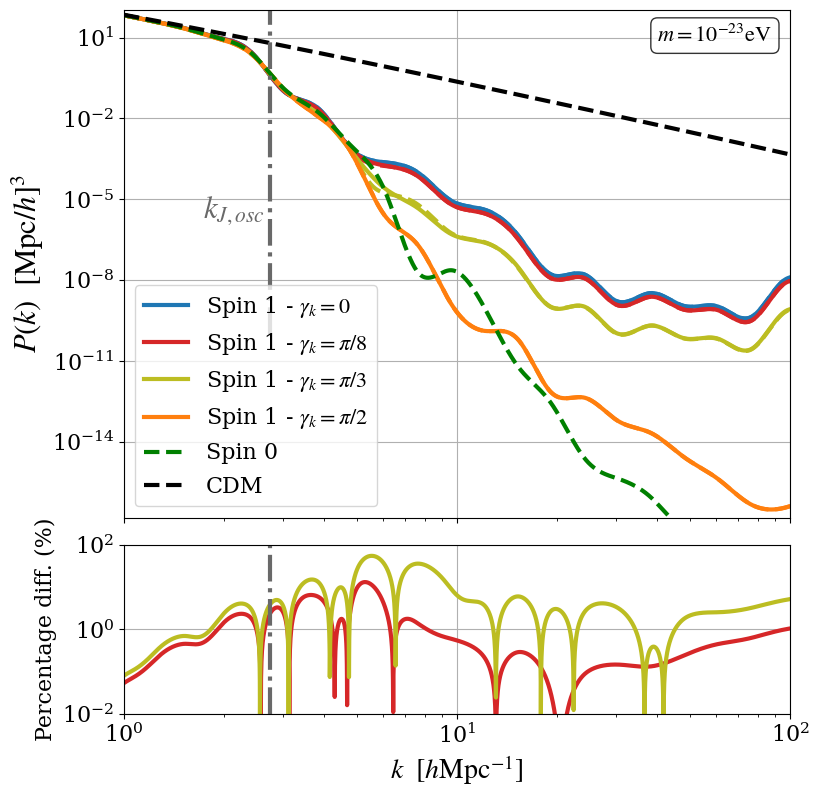

In [ ]:
# m = 10^{-23} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(0, np.log10(100),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        data_scf = np.loadtxt('../../SFDM_data/Pk_SFDM/Pk_SFDM_m=%s_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        k_scf = data_scf[:,0]  # first column
        Pk_scf = data_scf[:,1]  # second column      
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

        Pk_lcdm = [] # P(k) in (Mpc/h)**3

        k_grt_kj = []
        a_plot = []
        b_plot = []
        for k in kk:
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
            Pk.append(cosmo_angles[m].pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i]) * np.cos(angles[m])**(4)  for i in range(len(a_plot))]
        #array_fit = [b_plot[i] + (a_plot[i]+b_plot[i]-2*np.sqrt(a_plot[i]*b_plot[i])) * np.cos(angles[m])**(4) - 2*(b_plot[i]-np.sqrt(a_plot[i]*b_plot[i]))*np.cos(angles[m])**(2)  for i in range(len(a_plot))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'Spin 1 - $\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)

    axes[0].loglog(kk, Pk_scf, 'g--', label=r'Spin 0', lw=3)
    axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
    #axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
    axes[0].legend(loc='lower left',fontsize=14)
        #if m > 0:  
        #    axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(Pk)/np.array(data)))), color_angles[m], lw=3)
    axes[0].set_ylim([0.5*min(Pk), 1.5*max(Pk_lcdm)])
    axes[0].set_xlim([1.e0, 100])
    axes[0].vlines(kj, 1.e-10, 1.e4, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj, 1.e-2, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h\mathrm{Mpc}^{-1}]$', size=20)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=22)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=16)
    #axes[0].set_title('z=%s'%z0, fontsize=13)
    axes[0].text(40, 0.1*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=16)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    axes[0].text(0.63*kj, 2.e-6, r'$k_{J,osc}$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=22)
    axes[0].legend(loc='lower left', fontsize=16)
    fig.tight_layout()
    axes[0].tick_params(axis='both',labelsize=16)
    axes[1].tick_params(axis='both',labelsize=16)
    plt.savefig('../../Figures/Pk_parametrization_m=%s_z=%s_COMPARISON.pdf'%(str(mass)[-3:],str(z0)))
    plt.savefig('../../Figures/Pk_parametrization_m=%s_z=%s_COMPARISON.png'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)
#Pk_z0(20)

### $m = 10^{-24} eV$

In [ ]:
mass = 1.e-24
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

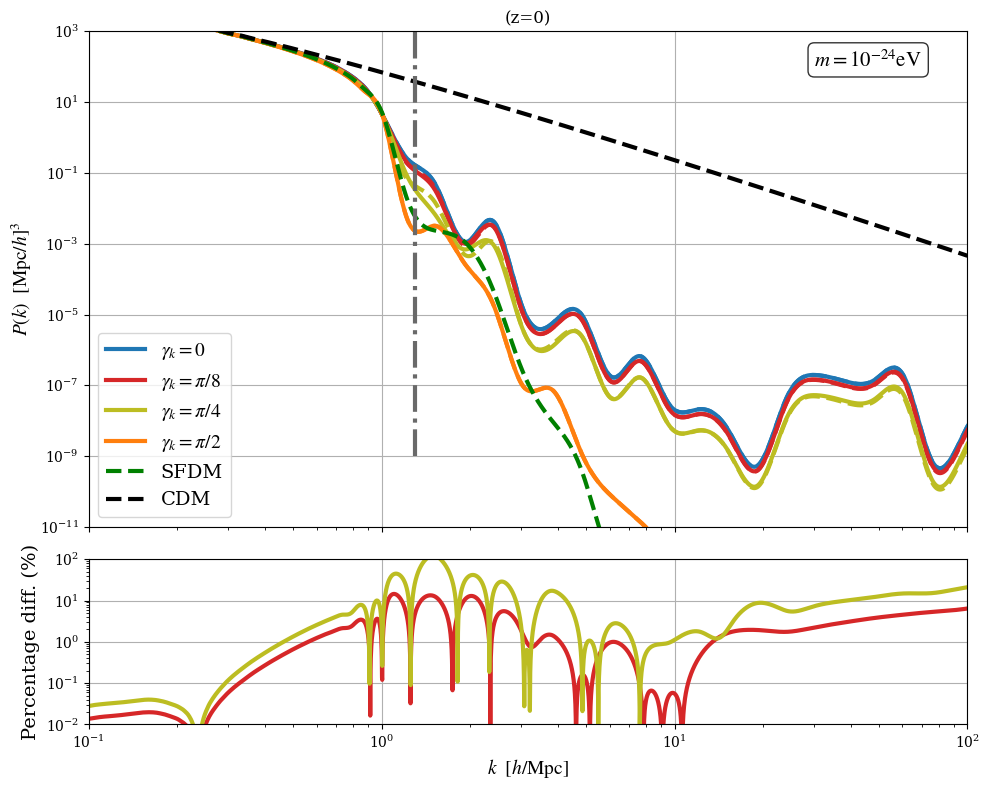

In [ ]:
# m = 10^{-24} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(100),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        data_scf = np.loadtxt('../../SFDM_data/Pk_SFDM/Pk_SFDM_m=%s_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        k_scf = data_scf[:,0]  # first column
        Pk_sfdm = data_scf[:,1]  # second column      
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

        Pk_lcdm = [] # P(k) in (Mpc/h)**3

        k_grt_kj = []
        a_plot = []
        b_plot = []
        for k in kk:
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
            Pk.append(cosmo_angles[m].pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i])* np.cos(angles[m])**(4) for i in range(len(a_plot))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)

    axes[0].loglog(kk, Pk_sfdm, 'g', linestyle='dashed', label=r'SFDM', lw=3)
    axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
    axes[0].legend(loc='lower left',fontsize=14)
    axes[0].set_ylim([1.e-11, 1.e3])
    axes[0].set_xlim([1.e-1, 100])
    axes[0].vlines(kj/h_planck, 1.e-9, max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(30, 100, r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    
        
    
    fig.tight_layout()
    #plt.savefig('/home/tomas/Dropbox/Doctorado/Spin 1/Cosmological Perturbations with VFDM CLASS/Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)

### $m = 10^{-25} eV$

In [17]:
mass = 1.e-25
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

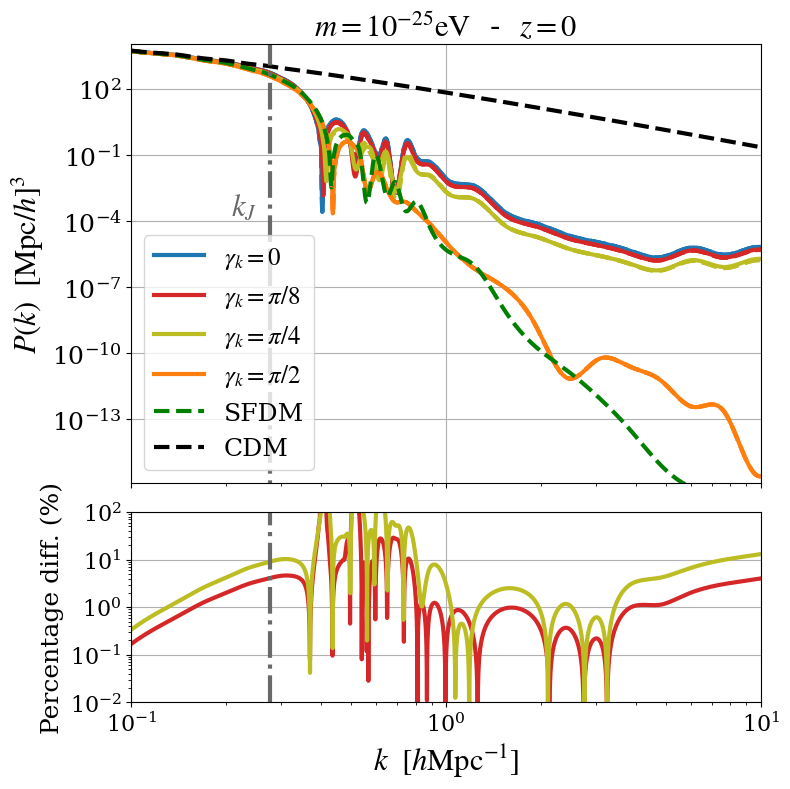

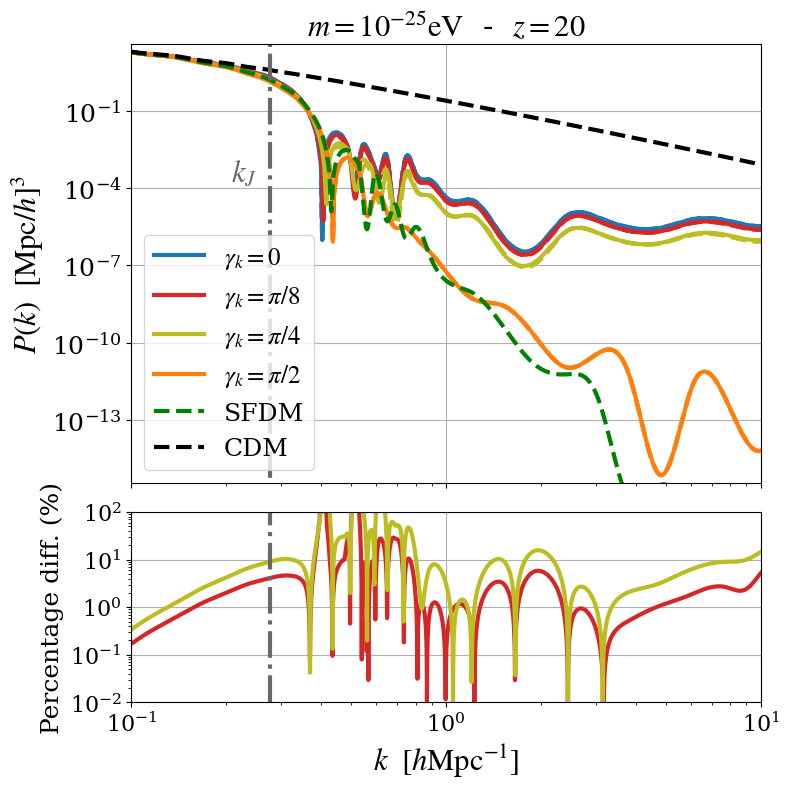

In [ ]:
# m = 10^{-25} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'tab:orange']
def Pk_z0(z0, ):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(100),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

        Pk_lcdm = [] # P(k) in (Mpc/h)**3

        a_plot = []
        b_plot = []
        for k in kk:
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
            Pk.append(cosmo_angles[m].pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        
        data_scf = np.loadtxt('../../SFDM_data/Pk_SFDM/Pk_SFDM_m=%s_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        k_scf = data_scf[:,0]  # first column
        Pk_sfdm = data_scf[:,1]  # second column   
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i]) * np.cos(angles[m])**(4)  for i in range(len(a_plot))]
        #array_fit = [b_plot[i] + (a_plot[i]+b_plot[i]-2*np.sqrt(a_plot[i]*b_plot[i])) * np.cos(angles[m])**(4) - 2*(b_plot[i]-np.sqrt(a_plot[i]*b_plot[i]))*np.cos(angles[m])**(2)  for i in range(len(a_plot))]
        #array_fit = [np.pow(np.sin(angles[m])**(2) *np.sqrt(a_plot[i]) + np.cos(angles[m])**(2) *np.sqrt(b_plot[i]), 2)  for i in range(len(a_plot))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
    axes[0].loglog(k_scf, Pk_sfdm, 'g--', label=r'SFDM', lw=3)
    axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
    axes[0].legend(loc='lower left',fontsize=14)
    axes[0].set_ylim([0.5*min(Pk), 2*max(Pk_lcdm)])
    axes[0].set_xlim([1.e-1, 10])
    axes[0].vlines(kj, 1.e-17, 1.e5, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj, 1.e-2, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h\mathrm{Mpc}^{-1}]$', size=22)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=22)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=18)
    axes[0].text(0.75*kj, 2.e-4, r'$k_{J}$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=22)
    axes[0].legend(loc='lower left', fontsize=18)
    axes[0].tick_params(axis='both',labelsize=18)
    axes[1].tick_params(axis='both',labelsize=16)
    axes[0].set_title(r'$m = 10^{%s} \rm{eV}$  -  $z = %s$' % (str(mass)[-3:], str(z0)), fontsize=22)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_parametrization_m=%s_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.savefig('../../Figures/Pk_parametrization_m=%s_z=%s.png'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)
Pk_z0(20)